### Clean Met PPSA

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [6]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import dates
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

# import rioxarray
# import rasterio 
import cfgrib
import os

In [7]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/ppsa'

## Open PPSA2 Station Observations

In [33]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
# filename = '/hdd/snow_hydrology/met_station/ppsa2/PPSA2.2026-03-20.csv'
df_met = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met['datetime'] = pd.to_datetime(df_met['utc_valid'], utc=True)
df_met = df_met.set_index('datetime')

df_met.columns

Index(['station', 'utc_valid', 'PCIRZZ', 'PCIRZZZ', 'RNIRZZ', 'SDIRZZ',
       'SDIRZZZ', 'TAIRZZ', 'TAIRZZZ', 'UDIRZZ', 'UHIRZZZ', 'UPIRZZ',
       'UPIRZZZ', 'USIRZZ', 'USIRZZZ', 'VBIRZZ', 'VBIRZZZ', 'XRIRZZ',
       'XRIRZZZ'],
      dtype='object')

Its not worth it trying to combine the old datasets with the new ones...

The station data looks really bad before WY2022 so we just need to work with whats good for now.

In [9]:
# # combine variables that are the same but changed name 
# # so PCIRZZ and PCIRZZZ are the same variable, just different names in different years, so combine them into one variable called PCIRZZZ
# df_met['precip_combined'] = df_met['PCIRZZ'].combine_first(df_met['PCIRZZZ'])
# df_met['hs_combined'] = df_met['SDIRZZZ'].combine_first(df_met['SDIRZZ'])
# df_met['temp_combined'] = df_met['TAIRZZZ'].combine_first(df_met['TAIRZZ'])
# # df_met['UPIRZZZ'] = df_met['UPIRZZZ'].combine_first(df_met['UPIRZZ']) # ignoring all the wind speed variables for now
# # df_met['USIRZZZ'] = df_met['USIRZZZ'].combine_first(df_met['USIRZZ'])
# df_met['rh_combined'] = df_met['XRIRZZZ'].combine_first(df_met['XRIRZZ'])

In [10]:
# do some general variable cleaning 

# remove precip values below 0 and above 1000
df_met['PCIRZZZ'] = df_met['PCIRZZZ'].where((df_met['PCIRZZZ'] >= 0) & (df_met['PCIRZZZ'] <= 1000), np.nan)

# remove relative humidity values below 0 and above 100
df_met['XRIRZZZ'] = df_met['XRIRZZZ'].where((df_met['XRIRZZZ'] >= 0) & (df_met['XRIRZZZ'] <= 100), np.nan)

# remove snow depth values below 0 and above 220 cm
df_met['SDIRZZZ'] = df_met['SDIRZZZ'].where((df_met['SDIRZZZ'] >= 0) & (df_met['SDIRZZZ'] <= 210), np.nan)

# remove temperature values below -50 and above 100 C
df_met['TAIRZZZ'] = df_met['TAIRZZZ'].where((df_met['TAIRZZZ'] >= -50) & (df_met['TAIRZZZ'] <= 100), np.nan)

## Convert from Pandas DF to Xarray DS

In [11]:
# create an xarray dataset, df_met, which contains only the variables PCIRZZZ, SDIRZZZ, TAIRZZZ, XRIRZZZ
df_met = df_met[['PCIRZZZ', 'SDIRZZZ', 'TAIRZZZ', 'XRIRZZZ']].copy()

df_met = df_met.copy()

# fix up the index 
df_met.index = pd.to_datetime(df_met.index, utc=True)
df_met = df_met.sort_index()

# remove timezone
df_met.index = df_met.index.tz_convert(None)

# then conver to xarray 
# ds_met = df_met.to_xarray()
ds_met = xr.Dataset.from_dataframe(df_met)

# and fix up the time coords, 
# ds_met = ds_met.assign_coords(
#     time=pd.to_datetime(ds_met.index, utc=True).tz_convert(None)
# ).swap_dims({'index': 'time'})

ds_met = ds_met.rename({'datetime': 'time'})
ds_met = ds_met.sel(time=slice("2019-10-01T05:00:00", "2025-09-30T05:00:00"))
ds_met

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 26248)
Coordinates:
  * time     (time) datetime64[ns] 210kB 2021-09-30T14:00:00 ... 2025-06-01
Data variables:
    PCIRZZZ  (time) float64 210kB 125.2 125.2 125.2 125.2 ... 87.6 87.64 87.68
    SDIRZZZ  (time) float64 210kB nan nan nan nan ... 16.07 16.76 15.96 15.78
    TAIRZZZ  (time) float64 210kB 38.19 37.58 38.53 38.7 ... 40.1 40.3 40.6 40.1
    XRIRZZZ  (time) float64 210kB 100.0 100.0 100.0 100.0 ... 92.1 91.5 92.9

# Data Cleaning

In [12]:
# ds_met['PCIRZZZ'] = ds_met['PCIRZZZ'].where(
#     (ds_met['PCIRZZZ'] >= 0) & (ds_met['PCIRZZZ'] <= 1000)
# )

# ds_met['XRIRZZZ'] = ds_met['XRIRZZZ'].where(
#     (ds_met['XRIRZZZ'] >= 0) & (ds_met['XRIRZZZ'] <= 100)
# )

# ds_met['SDIRZZZ'] = ds_met['SDIRZZZ'].where(
#     (ds_met['SDIRZZZ'] >= 0) & (ds_met['SDIRZZZ'] <= 210)
# )

# ds_met['TAIRZZZ'] = ds_met['TAIRZZZ'].where(
#     (ds_met['TAIRZZZ'] >= -50) & (ds_met['TAIRZZZ'] <= 100)
# )

# cleaning qc code (I've never used before)
def qc_range(da, vmin, vmax):
    return da.where((da >= vmin) & (da <= vmax))

ds_met['PCIRZZZ'] = qc_range(ds_met['PCIRZZZ'], 0, 1000)
ds_met['XRIRZZZ'] = qc_range(ds_met['XRIRZZZ'], 0, 100)
ds_met['SDIRZZZ'] = qc_range(ds_met['SDIRZZZ'], 0, 210)
ds_met['TAIRZZZ'] = qc_range(ds_met['TAIRZZZ'], -50, 100)

# and precip
ds_met['precip_accum'] = ds_met['PCIRZZZ'] * 25.4  # Convert inches to mm

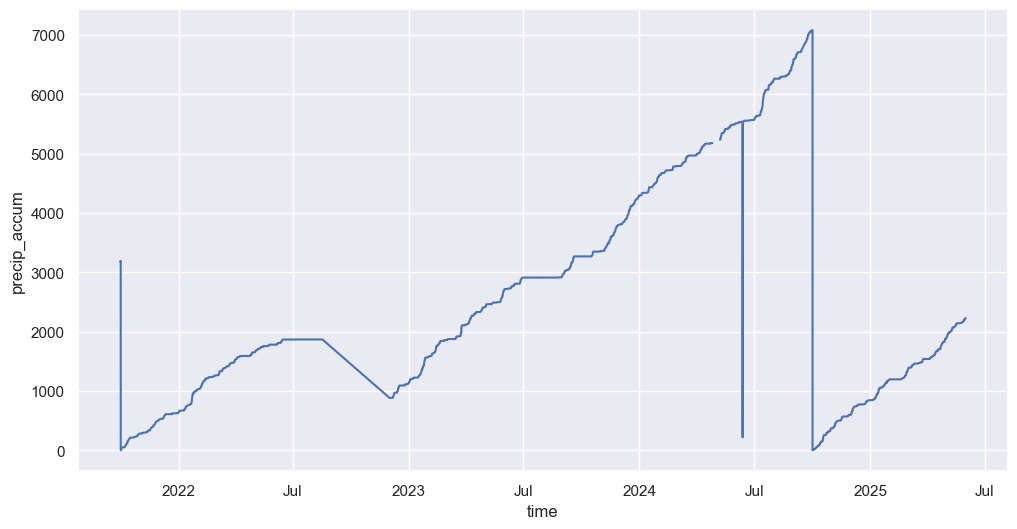

In [13]:
ds_met['precip_accum'].plot()

In [14]:
# PRECIP
# now we need to deal with precip
# we have total accumulated precip but we need precip per timestep for SNOWPACK 
# so first, calculate precip_rate from precip_accum (hourly timestep)
ds_met["precip_rate"] = ds_met["precip_accum"].diff("time") / 3600.0 # convert from mm/hr to mm/s for SNOWPACK
# and it can never be negative, so set any negative values to 0
ds_met["precip_rate"] = ds_met["precip_rate"].where(ds_met["precip_rate"] >= 0, 0)

# and if it is greater than 100 then set to nan
ds_met["precip_rate"] = ds_met["precip_rate"].where(ds_met["precip_rate"] < 0.03, np.nan)

# now calculate precip_accum_1hr for comparison with the HRRRAK precip variable (which is in mm/s but we can convert to mm/hr)
ds_met["precip_accum_1hr"] = ds_met["precip_rate"] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

# and if it is greater than 100 then set to nan
ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(ds_met["precip_accum_1hr"] < 100, np.nan)

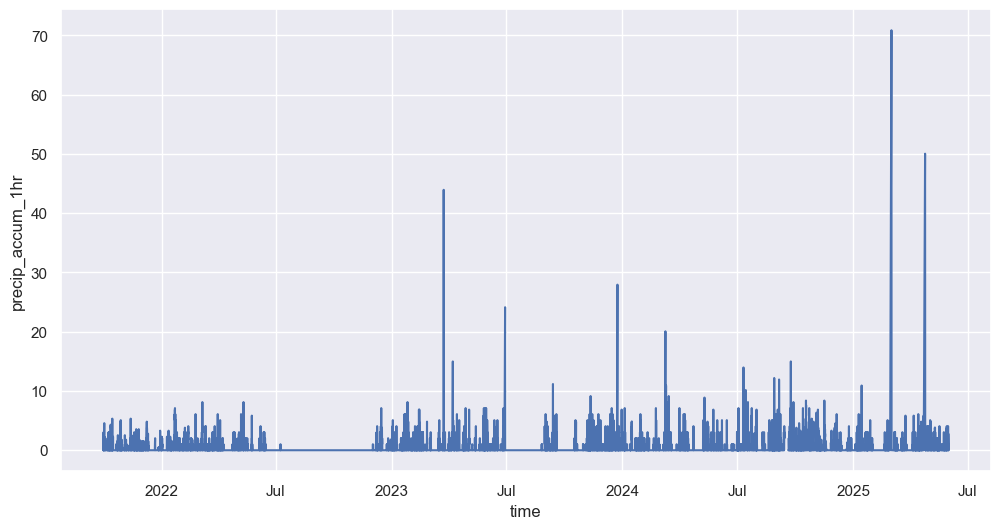

In [15]:
# ds_met['precip_rate'].plot()
ds_met['precip_accum_1hr'].plot()

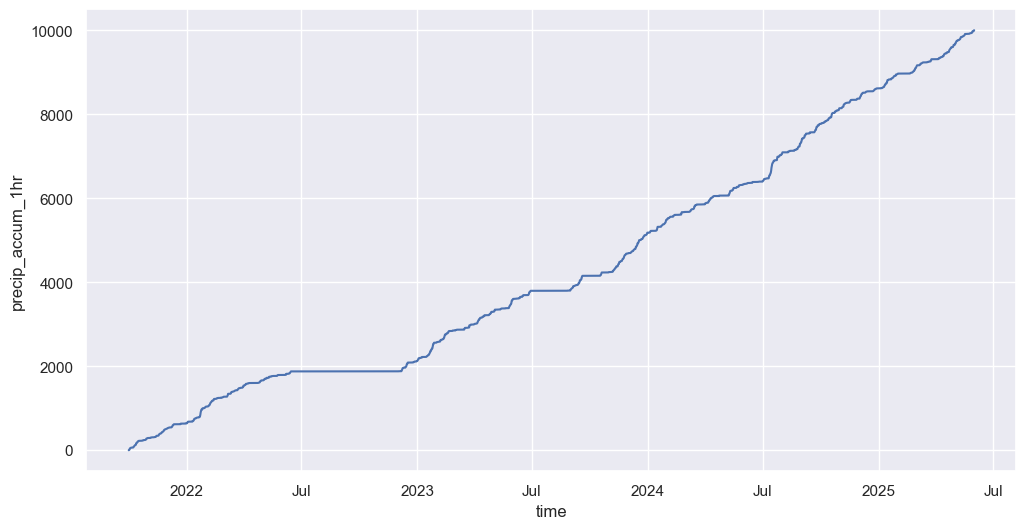

In [16]:
# ds_met['precip_accum'] = ds_met['precip_accum_1hr'].cumsum()
ds_met['precip_accum_1hr'].cumsum().plot()

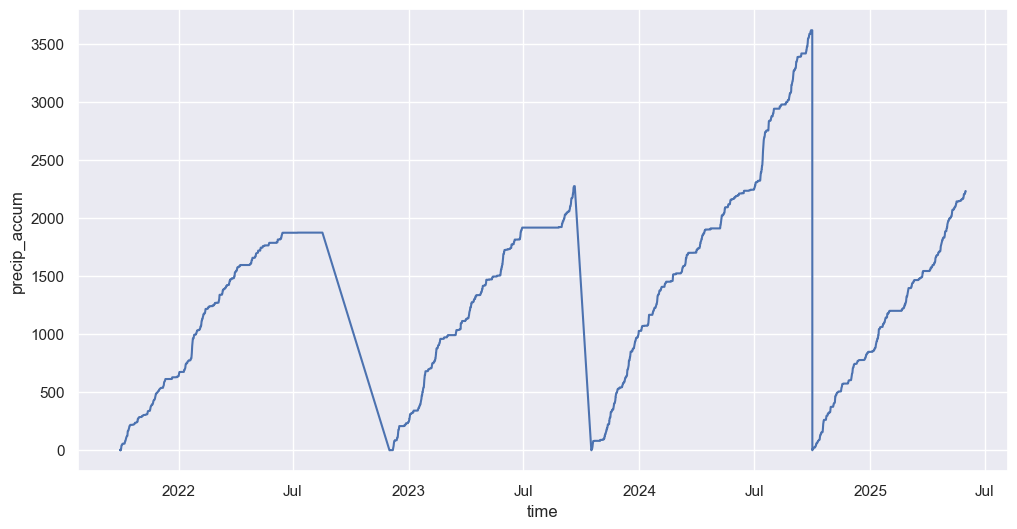

In [17]:
# Define water year
water_year = xr.where(
    ds_met.time.dt.month >= 10,
    ds_met.time.dt.year + 1,
    ds_met.time.dt.year
)

# Accumulated precipitation that resets every Oct 1
ds_met['precip_accum'] = (
    ds_met['precip_accum_1hr']
    .groupby(water_year)
    .cumsum(dim='time')
)

ds_met['precip_accum'].plot()

In [18]:
ds_met

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 26248)
Coordinates:
  * time              (time) datetime64[ns] 210kB 2021-09-30T14:00:00 ... 202...
Data variables:
    PCIRZZZ           (time) float64 210kB 125.2 125.2 125.2 ... 87.64 87.68
    SDIRZZZ           (time) float64 210kB nan nan nan nan ... 16.76 15.96 15.78
    TAIRZZZ           (time) float64 210kB 38.19 37.58 38.53 ... 40.3 40.6 40.1
    XRIRZZZ           (time) float64 210kB 100.0 100.0 100.0 ... 92.1 91.5 92.9
    precip_accum      (time) float64 210kB 0.0 0.0 0.0 ... 2.23e+03 2.231e+03
    precip_rate       (time) float64 210kB 0.0 0.0 0.0 ... 0.0002822 0.0002822
    precip_accum_1hr  (time) float64 210kB 0.0 0.0 0.0 0.0 ... 0.0 1.016 1.016

### Now, convert units 

In [19]:
ds_met

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 26248)
Coordinates:
  * time              (time) datetime64[ns] 210kB 2021-09-30T14:00:00 ... 202...
Data variables:
    PCIRZZZ           (time) float64 210kB 125.2 125.2 125.2 ... 87.64 87.68
    SDIRZZZ           (time) float64 210kB nan nan nan nan ... 16.76 15.96 15.78
    TAIRZZZ           (time) float64 210kB 38.19 37.58 38.53 ... 40.3 40.6 40.1
    XRIRZZZ           (time) float64 210kB 100.0 100.0 100.0 ... 92.1 91.5 92.9
    precip_accum      (time) float64 210kB 0.0 0.0 0.0 ... 2.23e+03 2.231e+03
    precip_rate       (time) float64 210kB 0.0 0.0 0.0 ... 0.0002822 0.0002822
    precip_accum_1hr  (time) float64 210kB 0.0 0.0 0.0 0.0 ... 0.0 1.016 1.016

In [20]:
# # resample the dataset hourly 
# df_met = df_met.resample('1H').mean()

In [21]:
# get all the variables consistent first 
ds_met['rh'] = ds_met['XRIRZZZ'] # already in percent, so no conversion needed
ds_met['hs'] = ds_met['SDIRZZZ'] * 2.54 # convert from inches to cm, this is the snow depth in cm

ds_met['temp'] = (ds_met['TAIRZZZ'] - 32) * 5/9 # convert from F to C

# and now drop the other variable names 
ds_met = ds_met.drop_vars(['PCIRZZZ', 'SDIRZZZ', 'TAIRZZZ', 'XRIRZZZ'])

# add attributes (if I convert this to a netcdf)
ds_met["temp"].attrs['units'] = 'C'
ds_met["rh"].attrs['units'] = 'percent'
ds_met['precip_accum'].attrs['units'] = 'mm'
# ds_met['precip_accum_1hr'].attrs['units'] = 'mm/hr'
ds_met['hs'].attrs['units'] = 'cm'


In [22]:
ds_met

<xarray.Dataset> Size: 1MB
Dimensions:           (time: 26248)
Coordinates:
  * time              (time) datetime64[ns] 210kB 2021-09-30T14:00:00 ... 202...
Data variables:
    precip_accum      (time) float64 210kB 0.0 0.0 0.0 ... 2.23e+03 2.231e+03
    precip_rate       (time) float64 210kB 0.0 0.0 0.0 ... 0.0002822 0.0002822
    precip_accum_1hr  (time) float64 210kB 0.0 0.0 0.0 0.0 ... 0.0 1.016 1.016
    rh                (time) float64 210kB 100.0 100.0 100.0 ... 92.1 91.5 92.9
    hs                (time) float64 210kB nan nan nan nan ... 42.57 40.54 40.08
    temp              (time) float64 210kB 3.439 3.1 3.628 ... 4.611 4.778 4.5

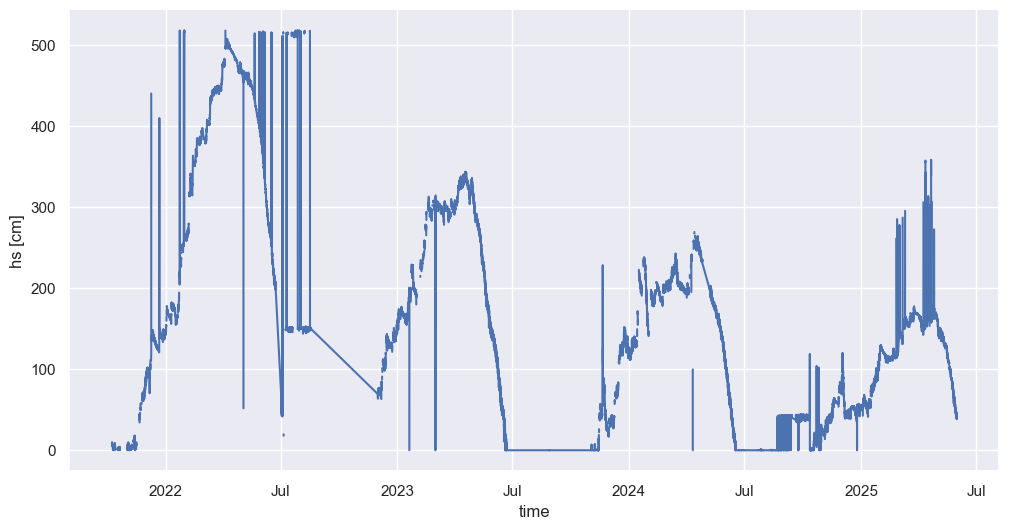

In [24]:
ds_met.hs.plot()

## Cleaning Snow Depth

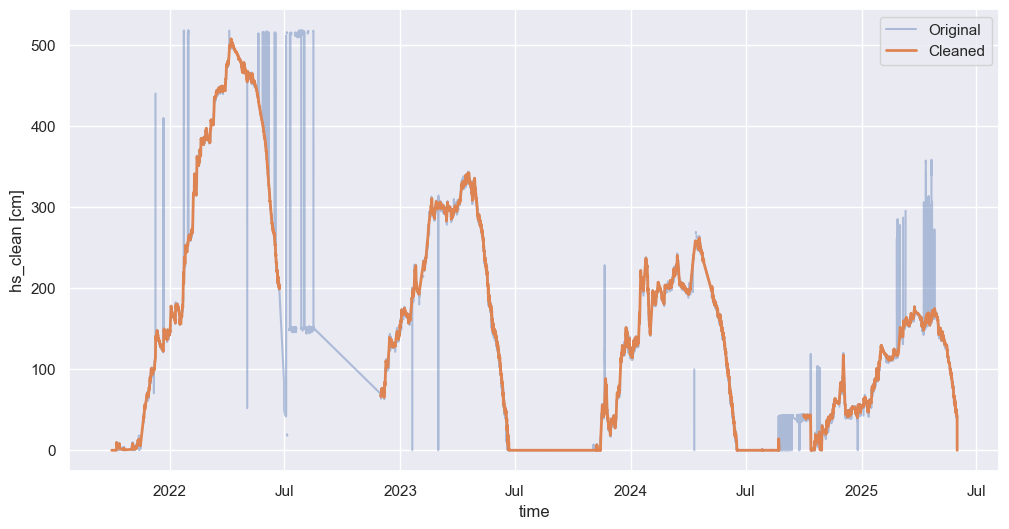

In [28]:
# -----------------------------------------------------------------------------
# CLEAN SNOW DEPTH (hs)
# -----------------------------------------------------------------------------

hs = ds_met['hs'].copy()

# Calculate timestep changes
dhs = hs.diff(dim='time')

# -----------------------------------------------------------------------------
# Define physically unrealistic changes
# -----------------------------------------------------------------------------

max_increase = 15.0   # cm per timestep
max_decrease = -20.0 # cm per timestep

bad_change = (
    (dhs > max_increase) |
    (dhs < max_decrease)
)

# Align dimensions
bad_change = xr.concat(
    [
        xr.DataArray(
            [False],
            coords={'time': [hs.time.values[0]]},
            dims='time'
        ),
        bad_change
    ],
    dim='time'
)

# -----------------------------------------------------------------------------
# Mask bad spikes
# -----------------------------------------------------------------------------

hs_clean = hs.where(~bad_change)

# -----------------------------------------------------------------------------
# Rolling median filter
# centered 5-point window
# -----------------------------------------------------------------------------

hs_clean = (
    hs_clean
    .rolling(time=5, center=True)
    .median()
)

# -----------------------------------------------------------------------------
# Fill gaps after filtering
# -----------------------------------------------------------------------------

hs_clean = hs_clean.interpolate_na(
    dim='time',
    method='linear'
)

# -----------------------------------------------------------------------------
# Remove tiny negatives
# -----------------------------------------------------------------------------

hs_clean = hs_clean.where(hs_clean >= 0, 0)

# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

ds_met['hs_clean'] = hs_clean

# finally remove the bad summer snow 

# Set snow depth >20 cm in July/August to NaN

bad_summer_snow = (
    (ds_met.time.dt.month.isin([7, 8, 9])) &
    (ds_met['hs_clean'] > 20)
)

ds_met['hs_clean'] = ds_met['hs_clean'].where(~bad_summer_snow)

# plot the two to compare 
plt.figure()
ds_met['hs'].plot(label='Original', alpha=0.4)
ds_met['hs_clean'].plot(label='Cleaned', linewidth=2)
plt.legend()

In [30]:
ds_met

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 26248)
Coordinates:
  * time              (time) datetime64[ns] 210kB 2021-09-30T14:00:00 ... 202...
Data variables:
    precip_accum      (time) float64 210kB 0.0 0.0 0.0 ... 2.23e+03 2.231e+03
    precip_rate       (time) float64 210kB 0.0 0.0 0.0 ... 0.0002822 0.0002822
    precip_accum_1hr  (time) float64 210kB 0.0 0.0 0.0 0.0 ... 0.0 1.016 1.016
    rh                (time) float64 210kB 100.0 100.0 100.0 ... 92.1 91.5 92.9
    hs                (time) float64 210kB nan nan nan nan ... 42.57 40.54 40.08
    temp              (time) float64 210kB 3.439 3.1 3.628 ... 4.611 4.778 4.5
    hs_clean          (time) float64 210kB 0.0 0.0 0.0 0.0 ... 40.82 0.0 0.0

In [31]:
# for hs the hs_final so replace that 
ds_met['hs'] = ds_met['hs_clean']
ds_met = ds_met.drop_vars('hs_clean')
ds_met

<xarray.Dataset> Size: 1MB
Dimensions:           (time: 26248)
Coordinates:
  * time              (time) datetime64[ns] 210kB 2021-09-30T14:00:00 ... 202...
Data variables:
    precip_accum      (time) float64 210kB 0.0 0.0 0.0 ... 2.23e+03 2.231e+03
    precip_rate       (time) float64 210kB 0.0 0.0 0.0 ... 0.0002822 0.0002822
    precip_accum_1hr  (time) float64 210kB 0.0 0.0 0.0 0.0 ... 0.0 1.016 1.016
    rh                (time) float64 210kB 100.0 100.0 100.0 ... 92.1 91.5 92.9
    hs                (time) float64 210kB 0.0 0.0 0.0 0.0 ... 40.82 0.0 0.0
    temp              (time) float64 210kB 3.439 3.1 3.628 ... 4.611 4.778 4.5

# Save to a new netcdf file, 

In [35]:
# save the first version of the cleaned data 
# filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
file = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_1June2025"  # should really replace this with the WY2026 data once I fix that...
ds_met.to_netcdf(file)